# Irradiation Study

In [1]:
# get data
from pathlib import Path

import numpy as np
from tqdm import tqdm
from superconductivity.utilities.constants import G0_muS
from superconductivity.evaluation import FileSpec
from superconductivity.evaluation import KeysSpec
from superconductivity.evaluation import get_keys
from superconductivity.evaluation import Keys
from superconductivity.utilities.meta.axis import axis
from superconductivity.evaluation import TraceSpec
from superconductivity.evaluation import get_traces
from superconductivity.evaluation import SamplingSpec
from superconductivity.evaluation import sample

filespec = FileSpec(
    h5path="OI-24d-10, 24-07-31, irradiation study, 0-0.80V, 7.75-8.05GHz 0.hdf5",
    location="/Volumes/speedyboy/TB/24 07 31 irradiation study",
    measurement="vna_irradiations",
)

all_keysspec = KeysSpec(
    strip0=None,
    strip1=None,
    remove_key="no_irradiation",
)

tracespec = TraceSpec(
    AmpV=1000,
    AmpI=1000,
    trigger_values=1,
    skip_edges=5,
)

Delta_meV = 0.20228599306311565
GN_G0 = 0.09253487133260037
Vbins = np.linspace(-4, 4, 2001)
Vbins_mV = Vbins * Delta_meV
Ibins_nA = Vbins_mV * GN_G0 * G0_muS

samplingspec = SamplingSpec(
    Vbins_mV=Vbins_mV,
    Ibins_nA=Ibins_nA,
    cutoff_Hz=13.7,
    sampling_Hz=1370.0,
    median_bins=3,
    sigma_bins=2.0,
)

all_keys = get_keys(
    filespec=filespec,
    keysspec=all_keysspec,
)
nu_GHz = np.arange(7.75, 8.05, 0.01)
Aout_mV = axis("Aout_mV", values=np.arange(0, 810.0, 10))

for i, nui_GHz in enumerate(tqdm(nu_GHz)):

    filespec = filespec
    tracespec = tracespec
    samplingspec = samplingspec

    short = f"{nui_GHz:6.4f}GHz_"
    matches = [s for s in all_keys.skeys if short in s]
    skeys = ["no_irradiation"] + matches

    trace_keys = Keys(
        skeys=skeys,
        indices=np.arange(0, len(matches) + 1, 1),
        yaxis=Aout_mV,
    )

    traces = get_traces(
        filespec=filespec,
        keys=trace_keys,
        tracespec=tracespec,
    )

    exp_v, exp_i = sample(
        traces=traces,
        samplingspec=samplingspec,
        show_progress=False,
    )

    out_path = Path(f"irradiation/nu_{nui_GHz:3.2f}GHz/eva.npz")
    out_path.parent.mkdir(parents=True, exist_ok=True)

    np.savez_compressed(
        out_path,
        Vbias_mV=exp_v["V_mV"],
        Ibias_nA=exp_i["I_nA"],
        Aout_mV=exp_v["Aout_mV"],
        nu_GHz=nui_GHz,
        Tbath_K=traces.Tsample_K,
        dGexp_G0=exp_v["dG_G0"],
        dRexp_R0=exp_i["dR_R0"],
        Iexp_nA=exp_v["I_nA"],
    )

100%|██████████| 31/31 [09:02<00:00, 17.51s/it]


# Frequency Study

In [ ]:
# # generate cache
# from superconductivity.utilities import make_cache, save_cache

# cache = make_cache(name="cache", path="nu0_0.5V/")
# save_cache(cache)

PosixPath('nu0_0.5V/cache.pkl')

In [23]:
# load cache
from superconductivity.utilities import load_cache, save_cache

cache = load_cache("cache", path="nu0_0.5V/")

In [ ]:
# get data
from superconductivity.evaluation import FileSpec

cache.filespec = FileSpec(
    h5path="OI-24d-10 24-07-30 frequency study at 0.5V, 7.7 to 8 GHz 2.hdf5",
    location="/Volumes/speedyboy/TB/24 07 30 frequency study, 0.5V, 7.7-8 GHz",
    measurement="vna_frequencies_0.500V",
)
mkeys = cache.filespec.mkeys()
skeys = cache.filespec.skeys()
_ = save_cache(cache)

['vna_frequencies_0.500V']

In [25]:
# get keys
from superconductivity.evaluation import KeysSpec
from superconductivity.evaluation import get_keys

cache.keysspec = KeysSpec(
    strip0="vna_",
    strip1="GHz_0.500V",
    remove_key="no_irradiation",
    add_key=[
        ("no_irradiation", 0.0),
    ],
    limits=(None, None),
    norm=1,
    label="nu_GHz",
)

cache.skeys = get_keys(
    filespec=cache.filespec,
    keysspec=cache.keysspec,
)
_ = save_cache(cache)

In [26]:
# get traces
from superconductivity.evaluation import TraceSpec
from superconductivity.evaluation import get_traces

cache.tracespec = TraceSpec(
    AmpV=1000,
    AmpI=1000,
    trigger_values=1,
    skip_edges=5,
)

cache.traces = get_traces(
    filespec=cache.filespec,
    keysspec=cache.keysspec,
    tracespec=cache.tracespec,
)
_ = save_cache(cache)

In [27]:
# sampling

from superconductivity.evaluation import SamplingSpec
from superconductivity.evaluation import sample
import numpy as np

cache.samplingspec = SamplingSpec(
    Vbins_mV=np.linspace(-0.9, 0.9, 901),
    Ibins_nA=np.linspace(-6.0, 6.0, 601),
    cutoff_Hz=13.7,
    sampling_Hz=137.0,
    median_bins=3,
    sigma_bins=2.0,
)

cache.samplingspec.keys()

cache.exp_v, cache.exp_i = sample(
    traces=cache.traces,
    samplingspec=cache.samplingspec,
)
_ = save_cache(cache)

sampling:   0%|          | 0/32 [00:00<?, ?trace/s]

In [30]:
# save data
import numpy as np

np.savez_compressed(
    "nu0_0.5V/eva.npz",
    Vbias_mV=cache.exp_v["V_mV"],
    Ibias_nA=cache.exp_i["I_nA"],
    nu_GHz=cache.exp_v["nu_GHz"],
    Aout_mV=0.5,
    dGexp_G0=cache.exp_v["dG_G0"],
    dRexp_R0=cache.exp_i["dR_R0"],
    Iexp_nA=cache.exp_v["I_nA"],
)

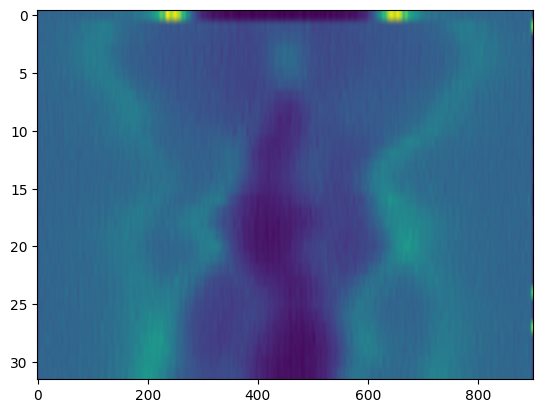

In [29]:
import matplotlib.pyplot as plt

plt.imshow(cache.exp_v["dG_G0"], aspect="auto")

# Frequency Study 0.4V Full Range

In [36]:
# # generate cache
# from superconductivity.utilities import make_cache, save_cache

# cache = make_cache(name="cache", path="nu1_0.4V/")
# save_cache(cache)

In [37]:
# load cache
from superconductivity.utilities import load_cache, save_cache

cache = load_cache("cache", path="nu1_0.4V/")

In [ ]:
# get data
from superconductivity.evaluation import FileSpec

cache.filespec = FileSpec(
    h5path="OI-24d-10 24-07-30 frequency study at 0.5V, 7.7 to 8 GHz 2.hdf5",
    location="/Volumes/speedyboy/TB/24 07 30 frequency study, 0.5V, 7.7-8 GHz",
    measurement="vna_frequencies_0.500V",
)
mkeys = cache.filespec.mkeys()
skeys = cache.filespec.skeys()
_ = save_cache(cache)

['vna_frequencies_0.500V']

In [ ]:
# get keys
from superconductivity.evaluation import KeysSpec
from superconductivity.evaluation import get_keys

cache.keysspec = KeysSpec(
    strip0="vna_",
    strip1="GHz_0.500V",
    remove_key="no_irradiation",
    add_key=[
        ("no_irradiation", 0.0),
    ],
    limits=(None, None),
    norm=1,
    label="nu_GHz",
)

cache.skeys = get_keys(
    filespec=cache.filespec,
    keysspec=cache.keysspec,
)
_ = save_cache(cache)

In [ ]:
# get traces
from superconductivity.evaluation import TraceSpec
from superconductivity.evaluation import get_traces

cache.tracespec = TraceSpec(
    AmpV=1000,
    AmpI=1000,
    trigger_values=1,
    skip_edges=5,
)

cache.traces = get_traces(
    filespec=cache.filespec,
    keysspec=cache.keysspec,
    tracespec=cache.tracespec,
)
_ = save_cache(cache)

In [ ]:
# sampling

from superconductivity.evaluation import SamplingSpec
from superconductivity.evaluation import sample
import numpy as np

cache.samplingspec = SamplingSpec(
    Vbins_mV=np.linspace(-0.9, 0.9, 901),
    Ibins_nA=np.linspace(-6.0, 6.0, 601),
    cutoff_Hz=13.7,
    sampling_Hz=137.0,
    median_bins=3,
    sigma_bins=2.0,
)

cache.samplingspec.keys()

cache.exp_v, cache.exp_i = sample(
    traces=cache.traces,
    samplingspec=cache.samplingspec,
)
_ = save_cache(cache)

sampling:   0%|          | 0/32 [00:00<?, ?trace/s]

In [ ]:
# save data
import numpy as np

np.savez_compressed(
    "nu0_0.5V/eva.npz",
    Vbias_mV=cache.exp_v["V_mV"],
    Ibias_nA=cache.exp_i["I_nA"],
    nu_GHz=cache.exp_v["nu_GHz"],
    Aout_mV=0.5,
    dGexp_G0=cache.exp_v["dG_G0"],
    dRexp_R0=cache.exp_i["dR_R0"],
    Iexp_nA=cache.exp_v["I_nA"],
)

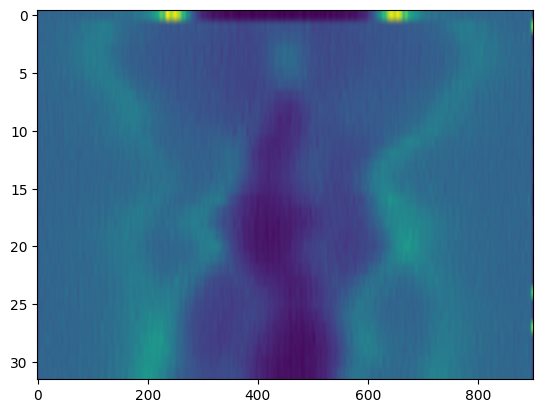

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(cache.exp_v["dG_G0"], aspect="auto")